In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"../data/kidney_disease.csv")

# Display basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nUnique values in target column (if present):")
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")  # preview first 10 unique values


Shape: (400, 26)

Columns:
 Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

Missing values per column:
 id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

Unique values in target column (if present):
id: [0 1 2 3 4 5 6 7 8 9]
age: [48.  7. 62. 51. 60. 68. 24. 52. 53. 50.]
bp: [ 80.  5

Shape: (400, 26)
Columns: Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

Missing values per column:
 id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

--- Dataset Summary ---
               age          bp          sg          al          su     rbc  \
count   391.000000  388.000000

C:\Users\jaint\AppData\Local\Temp\ipykernel_27412\4240359385.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
C:\Users\jaint\AppData\Local\Temp\ipykernel_27412\4240359385.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['classification'] = df['classification'].replace({'ckd': 1, 'ckd\t': 1, 'notckd': 0})


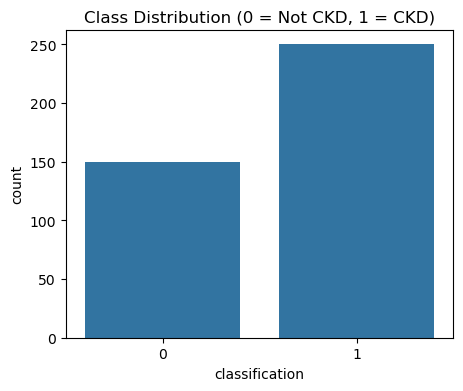

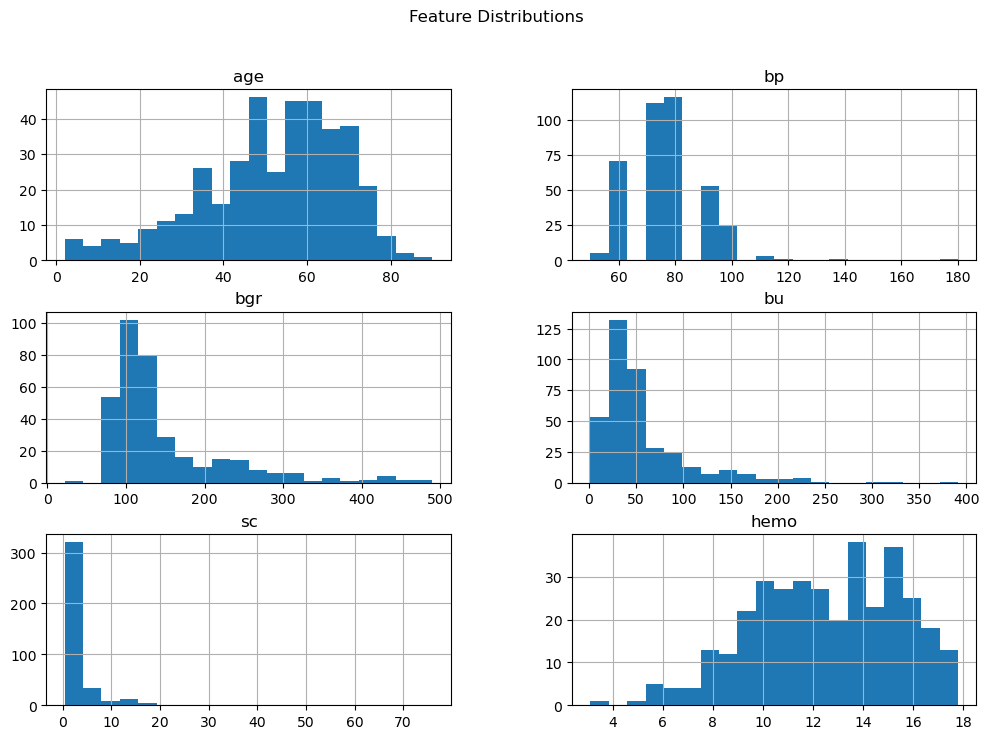

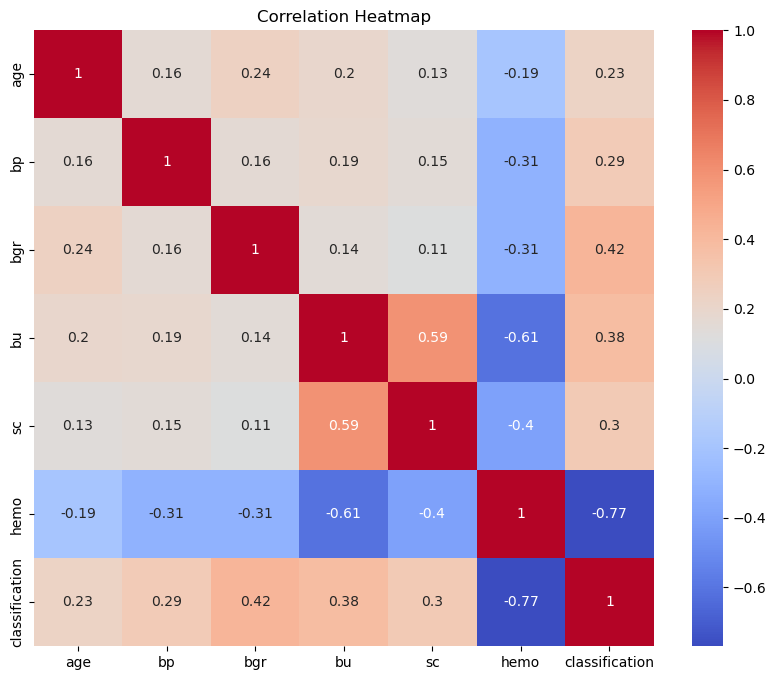


==== Logistic Regression ====
Accuracy: 0.9875
ROC-AUC: 1.0000
Confusion Matrix:
 [[30  0]
 [ 1 49]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


==== Random Forest ====
Accuracy: 1.0000
ROC-AUC: 1.0000
Confusion Matrix:
 [[30  0]
 [ 0 50]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


==== SVM ====
Accuracy: 0.9875
ROC-AUC: 1.0000
Confusion Matrix:
 [[30  0]
 [ 1 49]]
Classification

C:\Users\jaint\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [11:51:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\jaint\AppData\Local\Temp\ipykernel_27412\4240359385.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


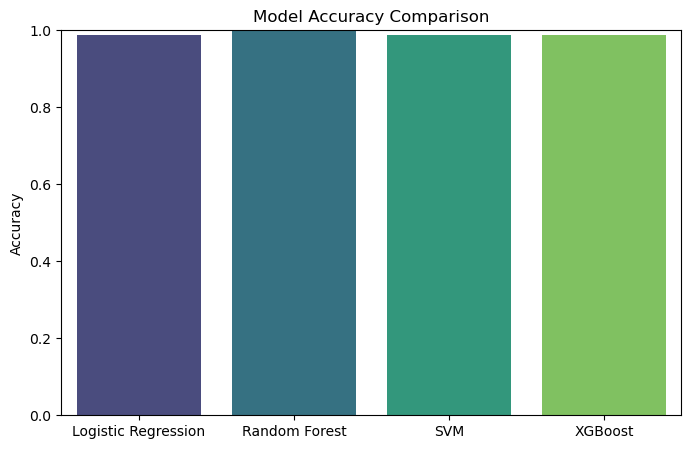

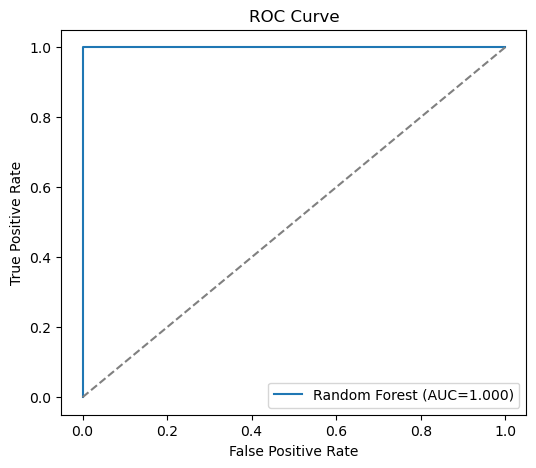


✅ Best model saved as 'best_ckd_model.pkl' (Random Forest) with accuracy 1.0000


In [4]:
# ===============================
# Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

# ===============================
# Load and Inspect Data
# ===============================
df = pd.read_csv(r"..\data\kidney_disease.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)
print("\nMissing values per column:\n", df.isnull().sum())

# Drop ID column
df.drop('id', axis=1, inplace=True)

# Clean text and target
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df['classification'] = df['classification'].replace({'ckd': 1, 'ckd\t': 1, 'notckd': 0})

# Replace '?' or similar with NaN
df.replace('?', np.nan, inplace=True)

# ===============================
# EDA (Exploratory Data Analysis)
# ===============================
print("\n--- Dataset Summary ---")
print(df.describe(include='all'))

# Class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='classification', data=df)
plt.title("Class Distribution (0 = Not CKD, 1 = CKD)")
plt.show()

# Distribution of a few numeric features
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'hemo']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols + ['classification']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# Data Preprocessing
# ===============================
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 
                'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ===============================
# Split Data
# ===============================
X = df.drop('classification', axis=1)
y = df['classification']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Model Training and Evaluation
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
best_acc = 0
best_model = None
best_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    results[name] = acc
    
    print(f"\n==== {name} ====")
    print(f"Accuracy: {acc:.4f}")
    if auc:
        print(f"ROC-AUC: {auc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name

# ===============================
# Model Comparison Visualization
# ===============================
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# ===============================
# ROC Curve for Best Model
# ===============================
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{best_name} (AUC={roc_auc_score(y_test, y_prob):.3f})")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# ===============================
# Save Best Model
# ===============================
joblib.dump(best_model, "../model/best_ckd_model.pkl")
print(f"\n✅ Best model saved as 'best_ckd_model.pkl' ({best_name}) with accuracy {best_acc:.4f}")
